<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
C:\Users\user\AppData\Local\Temp\ipykernel_13120\3940421310.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


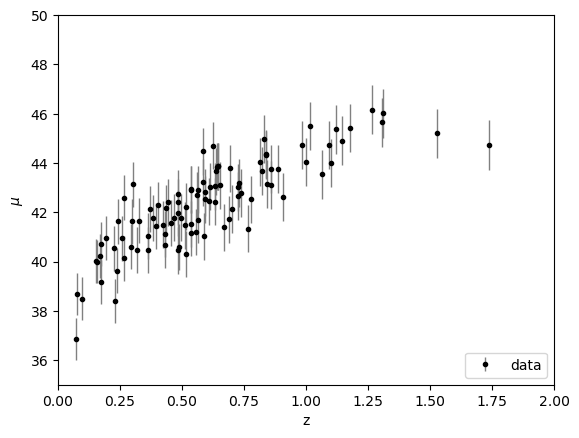

In [3]:
import numpy as np 
import matplotlib.pyplot as plt
from astroML.datasets import generate_mu_z

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [ ]:
#define the kernel and work on the error 

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF

kernel = ConstantKernel(1.0,(1e-3,1e3)) *  RBF(length_scale=10.0,length_scale_bounds=(1e-2,1e2))
gp = GaussianProcessRegressor(kernel=kernel,alpha=dmu**2,n_restarts_optimizer=10)
fit = gp.fit(z_sample[:,np.newaxis],mu_sample)

print("Optimized Kernel", gp.kernel_)

Optimized Kernel 30.7**2 * RBF(length_scale=3.9)


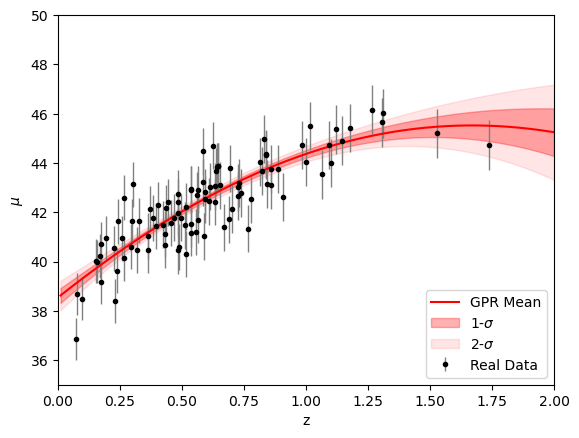

In [12]:
#fit, prediction and plot 

z_plot = np.linspace(0.01,2,1000)

mu_fit, sigma = gp.predict(z_plot[:,np.newaxis],return_std=True)

plt.errorbar(z_sample,mu_sample,dmu,fmt='.k', ecolor='gray', lw=1, label='Real Data')
plt.plot(z_plot,mu_fit, '-', color='red', label='GPR Mean')

plt.fill_between(z_plot,mu_fit-sigma,mu_fit+sigma,color='red', alpha=0.3, label='1-$\\sigma$')
plt.fill_between(z_plot, mu_fit - 2*sigma, mu_fit + 2*sigma, color='red', alpha=0.1, label='2-$\\sigma$')

plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.legend(loc='lower right')
plt.show()


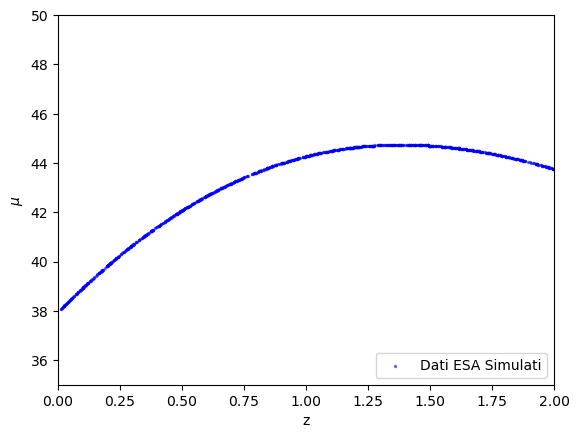

In [18]:
#clone the data 

z_simulated = np.random.uniform(0.01,2.0,1000)
mu_simulated = gp.sample_y(z_simulated[:,np.newaxis],n_samples=1)

plt.scatter(z_simulated, mu_simulated, color='blue', s=2, alpha=0.5, label='Dati ESA Simulati')
plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.legend(loc='lower right')
plt.show()


In [29]:
from scipy.integrate import OdeSolution
#part 3 physical parametric fit Lambda-CDM and MCMC 

import emcee 
import scipy.stats as scistast
import corner 
from astropy.cosmology import LambdaCDM

def model(z,H0,Om):
    cosmo_tmp = LambdaCDM(H0=H0, Om0=Om, Ode0=1-Om)
    return cosmo_tmp.distmod(z).value

def LogLikelihood(theta):
    Om, H0 = theta 
    if Om < 0: 
        return -np.inf
    
    mu_model = model(z_sample, H0, Om)

    return np.sum(scistast.norm(loc=mu_model,scale=dmu).logpdf(mu_sample))

def LogPrior(theta):
    Om, H0 = theta
    if 50 < H0 < 100 and 0.1 < Om < 1:

        return 0.0 
    return -np.inf

def LogPosterior(theta):
    return LogLikelihood(theta) + LogPrior(theta)


    

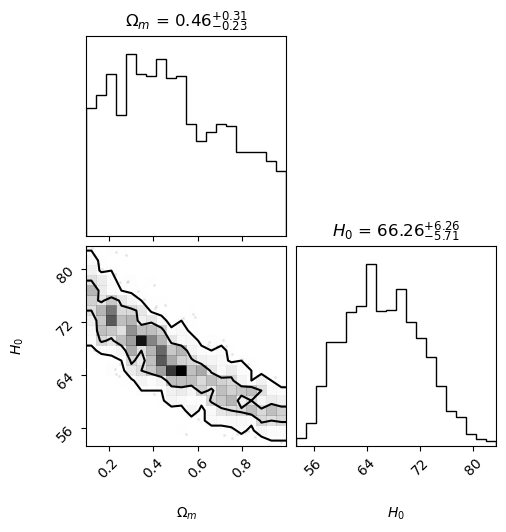

In [30]:
ndim = 2
nwalkers = 5 
nsteps = 5000

starting_guesses = np.array([0.5,80]) + 1e-1 * np.random.randn(nwalkers,ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior)
sampler.run_mcmc(starting_guesses,nsteps)

flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

fig = corner.corner(flat_samples, labels=["$\\Omega_m$", "$H_0$"], levels=[0.68, 0.95], show_titles=True)

